In [1]:
%load_ext autoreload
%autoreload 2

# Preprocess

In [2]:
import pandas as pd
from data_loader import load_and_preprocess_data, get_rolling_windows

In [3]:
df_merged = load_and_preprocess_data()
df_merged.to_csv('./data/1h/log_price.csv', index=False)
df_merged.head()

Data loading complete. Assets processed: ['BCH', 'LINK', 'ADA', 'XRP', 'ETH', 'ETC', 'BTC', 'LTC']


,timestamp,datetime_utc,BCH,LINK,ADA,XRP,ETH,ETC,BTC,LTC
0,1609459200000,2021-01-01T00:00:00+00:00,5.832820,2.422943,-1.712745,-1.506430,6.598591,1.739589,10.274823,4.819233
1,1609462800000,2021-01-01T01:00:00+00:00,5.857590,2.439648,-1.695541,-1.497002,6.618004,1.746936,10.289127,4.880451
2,1609466400000,2021-01-01T02:00:00+00:00,5.870200,2.449279,-1.692656,-1.497002,6.612484,1.753192,10.281732,4.894401
3,1609470000000,2021-01-01T03:00:00+00:00,5.860245,2.441999,-1.699089,-1.481485,6.613317,1.746239,10.284619,4.881210
4,1609473600000,2021-01-01T04:00:00+00:00,5.851973,2.438339,-1.705233,-1.430037,6.609632,1.754404,10.282338,4.874586


In [23]:
df_return = df_merged.copy()
target_cols = df_merged.columns.difference(['timestamp', 'datetime_utc'])
df_return[target_cols] = df_merged[target_cols].diff()
df_return.to_csv('./data/1h/log_return.csv', index=False)
df_return.head()

,timestamp,datetime_utc,BCH,LINK,ADA,XRP,ETH,ETC,BTC,LTC
0,1609459200000,2021-01-01T00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1609462800000,2021-01-01T01:00:00+00:00,0.024770,0.016705,0.017204,0.009428,0.019414,0.007348,0.014304,0.061218
2,1609466400000,2021-01-01T02:00:00+00:00,0.012610,0.009632,0.002884,0.000000,-0.005520,0.006255,-0.007395,0.013950
3,1609470000000,2021-01-01T03:00:00+00:00,-0.009956,-0.007280,-0.006433,0.015518,0.000833,-0.006953,0.002887,-0.013191
4,1609473600000,2021-01-01T04:00:00+00:00,-0.008272,-0.003660,-0.006144,0.051447,-0.003685,0.008165,-0.002281,-0.006623


In [4]:
rolling_data = get_rolling_windows(df_merged)
train_data, test_data = next(rolling_data)

In [26]:
train_data, test_data = next(rolling_data)
train_data

,timestamp,datetime_utc,BCH,LINK,ADA,XRP,ETH,ETC,BTC,LTC
168,1610064000000,2021-01-08T00:00:00+00:00,6.082036,2.735471,-1.231001,-1.134758,7.075961,1.961221,10.565858,5.108367
169,1610067600000,2021-01-08T01:00:00+00:00,6.083975,2.739097,-1.244795,-1.127012,7.077017,1.963329,10.562923,5.109152
170,1610071200000,2021-01-08T02:00:00+00:00,6.022600,2.685123,-1.281286,-1.219425,7.013574,1.919566,10.523607,5.036693
171,1610074800000,2021-01-08T03:00:00+00:00,6.040731,2.706382,-1.266309,-1.193692,7.047856,1.939029,10.554275,5.062089
172,1610078400000,2021-01-08T04:00:00+00:00,6.054134,2.712507,-1.259309,-1.167319,7.063596,1.934705,10.563057,5.084505
...,...,...,...,...,...,...,...,...,...,...
667,1611860400000,2021-01-28T19:00:00+00:00,5.974929,3.161162,-1.077781,-1.345920,7.194797,2.021415,10.390981,4.870070
668,1611864000000,2021-01-28T20:00:00+00:00,5.974522,3.146305,-1.066532,-1.344001,7.193994,2.021283,10.391460,4.870530
669,1611867600000,2021-01-28T21:00:00+00:00,5.995332,3.150340,-1.065922,-1.338648,7.206236,2.044203,10.409868,4.888694
670,1611871200000,2021-01-28T22:00:00+00:00,6.016474,3.151881,-1.062849,-1.326517,7.207304,2.042518,10.418157,4.898287


# Spread

In [8]:
from stats_model import screen_assets_with_spreads

In [27]:
screening_df, spreads_df = screen_assets_with_spreads(train_data)
screening_df

,Asset,Beta,Alpha,ADF_Stat,ADF_PValue,ADF_Lag,ADF_Pass,KSS_Stat,KSS_Lag,KSS_Pass,Kendall_Tau,Qualified
0,LTC,0.828308,6.342360,-1.831469,0.364954,3,False,-2.321564,1,True,0.729795,True
1,XRP,1.061079,11.792388,-2.555557,0.102535,2,False,-3.161574,2,True,0.700910,True
2,BCH,0.582225,6.886241,-2.361654,0.152853,2,False,-1.452724,0,False,0.623816,False
3,ETC,0.541673,9.369801,-1.806626,0.377177,1,False,-1.719607,0,False,0.337584,False
4,ADA,-0.103485,10.347974,-2.194777,0.208147,0,False,-2.805051,0,True,0.020087,True
5,ETH,-0.058687,10.880750,-2.142638,0.227719,0,False,-2.527679,0,True,-0.051755,True
6,LINK,-0.218170,11.110840,-2.634346,0.086104,0,True,-4.265365,0,True,-0.280225,True


In [28]:
spreads_df

,timestamp,datetime_utc,BCH,LINK,ADA,XRP,ETH,ETC,LTC
168,1610064000000,2021-01-08T00:00:00+00:00,0.138501,0.051816,0.090493,-0.022462,0.100376,0.133717,-0.007804
169,1610067600000,2021-01-08T01:00:00+00:00,0.134437,0.049671,0.086130,-0.033617,0.097502,0.129639,-0.011390
170,1610071200000,2021-01-08T02:00:00+00:00,0.130855,-0.001420,0.043038,0.025125,0.054463,0.114029,0.009313
171,1610074800000,2021-01-08T03:00:00+00:00,0.150967,0.033886,0.075256,0.028489,0.087143,0.134154,0.018946
172,1610078400000,2021-01-08T04:00:00+00:00,0.151945,0.044005,0.084763,0.009287,0.096849,0.145279,0.009160
...,...,...,...,...,...,...,...,...,...
667,1611860400000,2021-01-28T19:00:00+00:00,0.025985,-0.030189,-0.068528,0.026720,-0.067528,-0.073766,0.014702
668,1611864000000,2021-01-28T20:00:00+00:00,0.026701,-0.032951,-0.066885,0.025163,-0.067096,-0.073215,0.014800
669,1611867600000,2021-01-28T21:00:00+00:00,0.032993,-0.013662,-0.048414,0.037891,-0.047969,-0.067222,0.018163
670,1611871200000,2021-01-28T22:00:00+00:00,0.028972,-0.005038,-0.039807,0.033308,-0.039618,-0.058021,0.018505


# Copula

In [ ]:
from copula_engine import get_pseudo_observations, fit_best_copula

In [29]:
u = get_pseudo_observations(spreads_df['LTC'].values)
v = get_pseudo_observations(spreads_df['XRP'].values)
copula_result = fit_best_copula(u, v)
copula_result

{'type': 'frank',
 'theta': array([4.62415878]),
 'aic': np.float64(-217.33928977418648)}

# Backtest

In [24]:
from backtester import select_pairs, execute_trading_strategy

In [31]:
pairs_info = select_pairs(train_data)
results = execute_trading_strategy(test_data, pairs_info)
results

,timestamp,datetime_utc,strategy_return
672,1611878400000,2021-01-29T00:00:00+00:00,0.000000
673,1611882000000,2021-01-29T01:00:00+00:00,0.000000
674,1611885600000,2021-01-29T02:00:00+00:00,0.000000
675,1611889200000,2021-01-29T03:00:00+00:00,0.000000
676,1611892800000,2021-01-29T04:00:00+00:00,0.000000
...,...,...,...
835,1612465200000,2021-02-04T19:00:00+00:00,-0.007996
836,1612468800000,2021-02-04T20:00:00+00:00,-0.010341
837,1612472400000,2021-02-04T21:00:00+00:00,-0.035933
838,1612476000000,2021-02-04T22:00:00+00:00,0.023826


# Plot

In [35]:
import matplotlib.pyplot as plt
import numpy as np

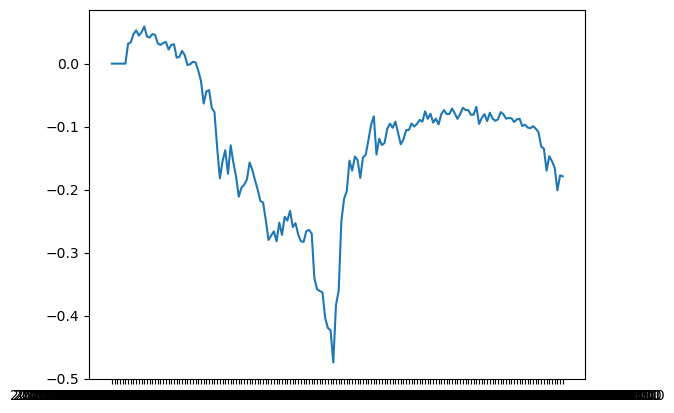

In [36]:
plt.plot(results['datetime_utc'], np.cumsum(results['strategy_return']), label='Strategy Cumulative Returns')
plt.show()

# Final Backtest

In [37]:
from backtester import run_full_backtest

In [39]:
backtest_config = {
    'train_hours': 504,    # 3 Weeks training
    'test_hours': 168,     # 1 Week testing
    'n_top': 2,            # Top 2 assets -> max 3 pairs
    'max_lag': 6,
    'alpha1': 0.1,         # Entry threshold
    'alpha2': 0.1         # Exit threshold
}
final_results = run_full_backtest(df_merged, backtest_config)
final_results

,timestamp,datetime_utc,strategy_return,cumulative_return
0,1611273600000,2021-01-22T00:00:00+00:00,0.000000,0.000000
1,1611277200000,2021-01-22T01:00:00+00:00,0.000000,0.000000
2,1611280800000,2021-01-22T02:00:00+00:00,0.000000,0.000000
3,1611284400000,2021-01-22T03:00:00+00:00,0.000000,0.000000
4,1611288000000,2021-01-22T04:00:00+00:00,0.000000,0.000000
...,...,...,...,...
43171,1766689200000,2025-12-25T19:00:00+00:00,0.000736,-0.186631
43172,1766692800000,2025-12-25T20:00:00+00:00,-0.000372,-0.187003
43173,1766696400000,2025-12-25T21:00:00+00:00,0.001147,-0.185856
43174,1766700000000,2025-12-25T22:00:00+00:00,-0.002128,-0.187984


In [42]:
final_results['datetime_utc'] = pd.to_datetime(final_results['datetime_utc'])
final_results

,timestamp,datetime_utc,strategy_return,cumulative_return
0,1611273600000,2021-01-22 00:00:00+00:00,0.000000,0.000000
1,1611277200000,2021-01-22 01:00:00+00:00,0.000000,0.000000
2,1611280800000,2021-01-22 02:00:00+00:00,0.000000,0.000000
3,1611284400000,2021-01-22 03:00:00+00:00,0.000000,0.000000
4,1611288000000,2021-01-22 04:00:00+00:00,0.000000,0.000000
...,...,...,...,...
43171,1766689200000,2025-12-25 19:00:00+00:00,0.000736,-0.186631
43172,1766692800000,2025-12-25 20:00:00+00:00,-0.000372,-0.187003
43173,1766696400000,2025-12-25 21:00:00+00:00,0.001147,-0.185856
43174,1766700000000,2025-12-25 22:00:00+00:00,-0.002128,-0.187984


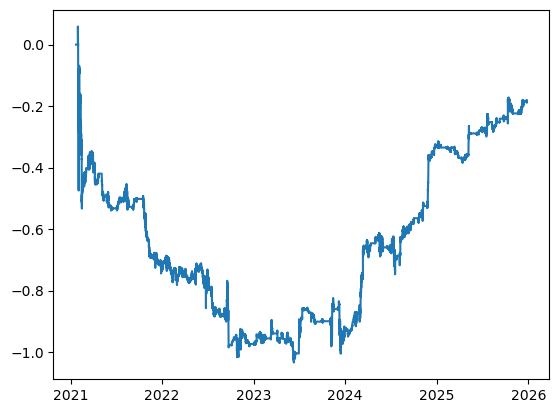

In [43]:
plt.plot(final_results['datetime_utc'], final_results['cumulative_return'], label='Strategy Cumulative Returns')
plt.show()